In [2]:
import pandas as pd
import numpy as np

df_ratings = pd.read_csv('Ratings.csv', sep=',')
df_ratings.head()

df_ratings.info()

df_users = pd.read_csv('Users.csv', sep=',')
df_users.head()

df_users.info()

df_books = pd.read_csv('Books.csv')
df_books.head()

df_books.info()

df_books.dropna(inplace=True)
df_books.info()

df_ratings_books = pd.merge(df_ratings, df_books, on='ISBN')
df_ratings_books.head()

df_ratings.shape

df_ratings_count = df_ratings_books.groupby('Book-Title').count()['Book-Rating'].reset_index()
df_ratings_count.head()

df_ratings_avg = df_ratings_books.groupby('Book-Title')['Book-Rating'].mean().reset_index()
df_ratings_avg.head()

df_ratings_total = pd.merge(df_ratings_count, df_ratings_avg, on='Book-Title')
df_ratings_total.head()

df_ratings_total.rename(columns={'Book-Rating_x': 'Rating-Count', 'Book-Rating_y': 'Rating-Avg'}, inplace=True)
df_ratings_total.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


C:\Users\Ryan\AppData\Local\Temp\ipykernel_19216\2870867838.py:14: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_books = pd.read_csv('Books.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 271353 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271353 non-null  object
 1   Book-Title           271353 non-null  object
 2   Book-Author          271353 non-null  o

,Book-Title,Rating-Count,Rating-Avg
0,A Light in the Storm: The Civil War Diary of ...,4,2.25
1,Always Have Popsicles,1,0.00
2,Apple Magic (The Collector's series),1,0.00
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.00
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.00


Max number of ratings: 2502
Min number of ratings: 1
Average number of ratings: 4.277385767324166
Max average rating: 10.0
Min average rating: 0.0
Overall average rating: 2.8900809963074625
Number of 0 ratings: 105502


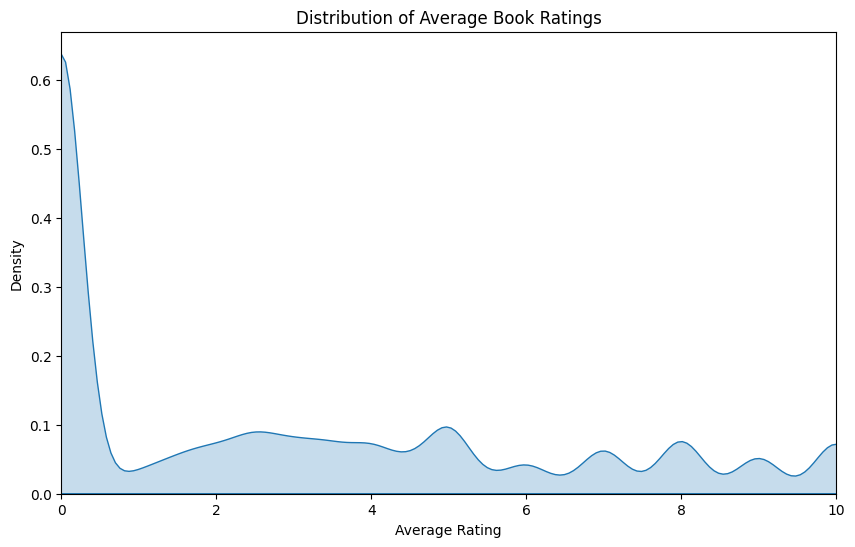

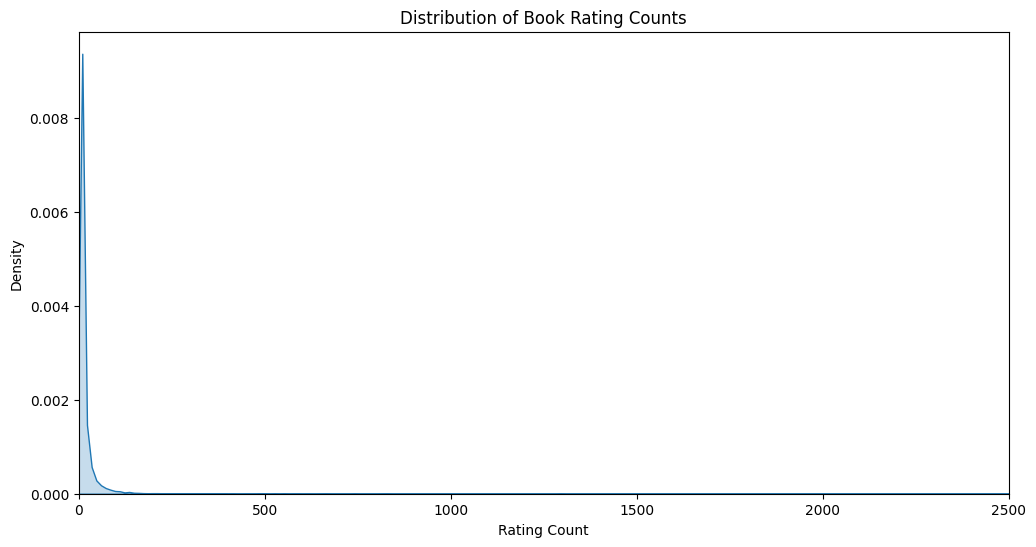

In [11]:
print(f'Max number of ratings: {df_ratings_total["Rating-Count"].max()}')
print(f'Min number of ratings: {df_ratings_total["Rating-Count"].min()}')
print(f'Average number of ratings: {df_ratings_total["Rating-Count"].mean()}')

print(f'Max average rating: {df_ratings_total["Rating-Avg"].max()}')
print(f'Min average rating: {df_ratings_total["Rating-Avg"].min()}')
print(f'Overall average rating: {df_ratings_total["Rating-Avg"].mean()}')


print('Number of 0 ratings:', df_ratings_total[df_ratings_total['Rating-Avg'] == 0].shape[0])


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.kdeplot(data=df_ratings_total, x='Rating-Avg', fill=True)
plt.title('Distribution of Average Book Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Density')
plt.xlim(0, 10)
plt.show()

plt.figure(figsize=(12,6))
sns.kdeplot(data=df_ratings_total, x='Rating-Count', fill=True)
plt.title('Distribution of Book Rating Counts')
plt.xlabel('Rating Count')
plt.ylabel('Density')
plt.xlim(0, 2500)
plt.show()



In [3]:
min_rating_count = 100
df_popular_ratings = df_ratings_total[df_ratings_total['Rating-Count'] >= min_rating_count]
df_popular_ratings.head()

# sort by average rating descending
df_popular_ratings = df_popular_ratings.sort_values(by='Rating-Avg', ascending=False)

df_popular_ratings.head(10)



,Book-Title,Rating-Count,Rating-Avg
80431,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804
80419,Harry Potter and the Goblet of Fire (Book 4),387,5.824289
195667,The Little Prince,141,5.815603
80438,Harry Potter and the Sorcerer's Stone (Book 1),278,5.737410
80423,Harry Potter and the Order of the Phoenix (Boo...,347,5.501441
60579,Ender's Game (Ender Wiggins Saga (Paperback)),249,5.409639
80411,Harry Potter and the Chamber of Secrets (Book 2),556,5.183453
201965,The Perks of Being a Wallflower,104,5.144231
191607,The Hobbit : The Enchanting Prelude to The Lor...,281,5.007117
187372,The Fellowship of the Ring (The Lord of the Ri...,368,4.948370


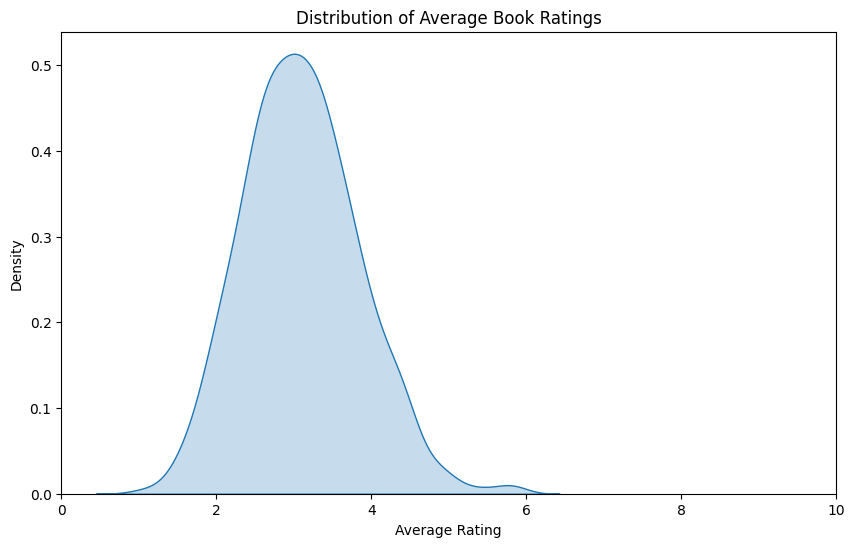

In [4]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df_popular_ratings, x='Rating-Avg', fill=True)
plt.title('Distribution of Average Book Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Density')
plt.xlim(0, 10)
plt.show()

In [5]:

df_popular_ratings = df_popular_ratings.merge(df_books, on='Book-Title')
df_popular_ratings.head()



,Book-Title,Rating-Count,Rating-Avg,ISBN,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804,0439136350,J. K. Rowling,1999,Scholastic,http://images.amazon.com/images/P/0439136350.0...,http://images.amazon.com/images/P/0439136350.0...,http://images.amazon.com/images/P/0439136350.0...
1,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804,0439136369,J. K. Rowling,2001,Scholastic,http://images.amazon.com/images/P/0439136369.0...,http://images.amazon.com/images/P/0439136369.0...,http://images.amazon.com/images/P/0439136369.0...
2,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804,0786222743,J. K. Rowling,2000,Thorndike Press,http://images.amazon.com/images/P/0786222743.0...,http://images.amazon.com/images/P/0786222743.0...,http://images.amazon.com/images/P/0786222743.0...
3,Harry Potter and the Goblet of Fire (Book 4),387,5.824289,0439139597,J. K. Rowling,2000,Scholastic,http://images.amazon.com/images/P/0439139597.0...,http://images.amazon.com/images/P/0439139597.0...,http://images.amazon.com/images/P/0439139597.0...
4,Harry Potter and the Goblet of Fire (Book 4),387,5.824289,0439139600,J. K. Rowling,2002,Scholastic Paperbacks,http://images.amazon.com/images/P/0439139600.0...,http://images.amazon.com/images/P/0439139600.0...,http://images.amazon.com/images/P/0439139600.0...


In [6]:
# drop url L, M size
df_popular_ratings = df_popular_ratings.drop(columns=['Image-URL-M', 'Image-URL-L'])
df_popular_ratings.head()





,Book-Title,Rating-Count,Rating-Avg,ISBN,Book-Author,Year-Of-Publication,Publisher,Image-URL-S
0,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804,0439136350,J. K. Rowling,1999,Scholastic,http://images.amazon.com/images/P/0439136350.0...
1,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804,0439136369,J. K. Rowling,2001,Scholastic,http://images.amazon.com/images/P/0439136369.0...
2,Harry Potter and the Prisoner of Azkaban (Book 3),428,5.852804,0786222743,J. K. Rowling,2000,Thorndike Press,http://images.amazon.com/images/P/0786222743.0...
3,Harry Potter and the Goblet of Fire (Book 4),387,5.824289,0439139597,J. K. Rowling,2000,Scholastic,http://images.amazon.com/images/P/0439139597.0...
4,Harry Potter and the Goblet of Fire (Book 4),387,5.824289,0439139600,J. K. Rowling,2002,Scholastic Paperbacks,http://images.amazon.com/images/P/0439139600.0...


In [7]:
print(f'Min number of ratings by user: {df_ratings.groupby("User-ID").count()["Book-Rating"].min()}')
print(f'Max number of ratings by user: {df_ratings.groupby("User-ID").count()["Book-Rating"].max()}')
print(f'Average number of ratings by user: {df_ratings.groupby("User-ID").count()["Book-Rating"].mean()}')

min_user_ratings = 100
df_active_users = df_ratings_books.groupby('User-ID').count()['Book-Rating'].reset_index()
df_active_users = df_active_users[df_active_users['Book-Rating'] >= min_user_ratings]
df_active_users.head()

# Lọc các đánh giá từ những người dùng hoạt động
df_active_ratings = df_ratings_books[df_ratings_books['User-ID'].isin(df_active_users['User-ID'])]
df_active_ratings.head()

df_active_ratings.shape

# Lọc các cuốn sách phổ biến từ các đánh giá của người dùng hoạt động
df_active_popular_ratings = df_active_ratings[df_active_ratings['Book-Title'].isin(df_popular_ratings['Book-Title'])]
df_active_popular_ratings.head()





Min number of ratings by user: 1
Max number of ratings by user: 13602
Average number of ratings by user: 10.920851419507423


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
1150,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...
1162,277427,006092988X,0,A Tree Grows in Brooklyn,Betty Smith,1998,Perennial,http://images.amazon.com/images/P/006092988X.0...,http://images.amazon.com/images/P/006092988X.0...,http://images.amazon.com/images/P/006092988X.0...
1163,277427,0060930535,0,The Poisonwood Bible: A Novel,Barbara Kingsolver,1999,Perennial,http://images.amazon.com/images/P/0060930535.0...,http://images.amazon.com/images/P/0060930535.0...,http://images.amazon.com/images/P/0060930535.0...
1165,277427,0060934417,0,Bel Canto: A Novel,Ann Patchett,2002,Perennial,http://images.amazon.com/images/P/0060934417.0...,http://images.amazon.com/images/P/0060934417.0...,http://images.amazon.com/images/P/0060934417.0...
1168,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,1995,HarperTorch,http://images.amazon.com/images/P/0061009059.0...,http://images.amazon.com/images/P/0061009059.0...,http://images.amazon.com/images/P/0061009059.0...


In [8]:
pivot_table = df_active_popular_ratings.pivot_table(index='Book-Title', columns='User-ID', values='Book-Rating')
pivot_table.head()

pivot_table.fillna(0, inplace=True)
pivot_table.head()

User-ID,254,507,882,1424,1435,1733,1903,2033,2110,2276,...,275020,275970,276463,276680,277427,277478,277639,278137,278188,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24 Hours,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
ratingDf = pd.read_csv('Ratings.csv')
bookDf = pd.read_csv('Books.csv')

ratingBookDf = ratingDf.merge(bookDf, on='ISBN')
ratingBookDf.info()
ratingBookDf[(ratingBookDf['Book-Title'] == '1984')]


C:\Users\Ryan\AppData\Local\Temp\ipykernel_19216\1010642862.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  bookDf = pd.read_csv('Books.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1031136 entries, 0 to 1031135
Data columns (total 10 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   User-ID              1031136 non-null  int64 
 1   ISBN                 1031136 non-null  object
 2   Book-Rating          1031136 non-null  int64 
 3   Book-Title           1031136 non-null  object
 4   Book-Author          1031134 non-null  object
 5   Year-Of-Publication  1031136 non-null  object
 6   Publisher            1031134 non-null  object
 7   Image-URL-S          1031136 non-null  object
 8   Image-URL-M          1031136 non-null  object
 9   Image-URL-L          1031132 non-null  object
dtypes: int64(2), object(8)
memory usage: 78.7+ MB


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
3276,278158,0451524934,0,1984,George Orwell,1990,Signet Book,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...
8304,278796,0451519841,0,1984,George Orwell,1980,New Amer Library,http://images.amazon.com/images/P/0451519841.0...,http://images.amazon.com/images/P/0451519841.0...,http://images.amazon.com/images/P/0451519841.0...
8935,254,0451524934,9,1984,George Orwell,1990,Signet Book,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...
11606,1706,0451524934,10,1984,George Orwell,1990,Signet Book,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...
12932,2179,0451524934,8,1984,George Orwell,1990,Signet Book,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...
...,...,...,...,...,...,...,...,...,...,...
1023006,274282,8423328651,10,1984,George Orwell,1998,La Marca Editora,http://images.amazon.com/images/P/8423328651.0...,http://images.amazon.com/images/P/8423328651.0...,http://images.amazon.com/images/P/8423328651.0...
1025889,274811,848328006X,0,1984,George Orwell,1997,"Plaza &amp; Janes Editores, S.A.",http://images.amazon.com/images/P/848328006X.0...,http://images.amazon.com/images/P/848328006X.0...,http://images.amazon.com/images/P/848328006X.0...
1027393,275520,0451524934,10,1984,George Orwell,1990,Signet Book,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...
1028671,275970,0451524934,0,1984,George Orwell,1990,Signet Book,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...,http://images.amazon.com/images/P/0451524934.0...


In [ ]:
from sklearn.metrics.pairwise import cosine_simihlarity
item_similarity = cosine_similarity(pivot_table)
item_similarity.shape

print(item_similarity[:4])

book = 'Harry Potter and the Chamber of Secrets (Book 2)'
book_index = pivot_table.index.tolist().index(book)
print(f'Index of the book "{book}":', book_index)

book_similarities = item_similarity[book_index]
print(book_similarities)

# Top 5 similar books
sorted_indexes = sorted(range(len(book_similarities)), key=lambda k: book_similarities[k], reverse=True)
for i in sorted_indexes[1:6]:
    print(f'Index: {i}, Similarity Score: {book_similarities[i]:.4f}, Book Title: {pivot_table.index[i]}')

[[1.         0.06550754 0.00972232 ... 0.07547772 0.05810769 0.03029366]
 [0.06550754 1.         0.07202902 ... 0.04739871 0.13548709 0.12388301]
 [0.00972232 0.07202902 1.         ... 0.02856084 0.04972988 0.01222063]
 [0.00805409 0.23629915 0.0779683  ... 0.02996956 0.04119689 0.07992925]]
Index of the book "Harry Potter and the Chamber of Secrets (Book 2)": 280
[0.0456812  0.05176796 0.04442684 0.06750352 0.         0.07538008
 0.         0.04411131 0.05441955 0.09503959 0.0127923  0.06591945
 0.         0.03351017 0.03739238 0.08606077 0.         0.02641902
 0.05389105 0.05130412 0.02248755 0.0793806  0.05027479 0.04439949
 0.09592007 0.07610648 0.09319769 0.07263204 0.0821942  0.05232993
 0.12889687 0.06869743 0.         0.10532938 0.0978699  0.01536267
 0.10390372 0.08655169 0.06754608 0.09822379 0.         0.0424137
 0.09071373 0.01309615 0.05193654 0.05651147 0.08963741 0.03352851
 0.07164605 0.05239969 0.08794692 0.08585707 0.09474281 0.09758223
 0.06175466 0.07563996 0.04639 

In [10]:
df_books = pd.read_csv('Books.csv')
df_books.head()


C:\Users\Ryan\AppData\Local\Temp\ipykernel_10952\2968811191.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_books = pd.read_csv('Books.csv')


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
